In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import re

# download necessary nltk data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')

print("all libraries imported successfully!")

[nltk_data] Downloading package punkt to /home/boss-lady/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /home/boss-
[nltk_data]     lady/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /home/boss-
[nltk_data]     lady/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/boss-lady/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt_tab to /home/boss-
[nltk_data]     lady/nltk_data...


all libraries imported successfully!


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [2]:
# create a dataset of 30 customer reviews
# mix of positive, negative and neutral

reviews = [
    # positive reviews
    "this product is absolutely amazing, i love it so much!",
    "excellent quality and very fast delivery, highly recommend",
    "best purchase i have ever made, works perfectly",
    "outstanding customer service, they were so helpful",
    "fantastic product, exceeded all my expectations",
    "very happy with my order, great value for money",
    "superb quality, will definitely buy again",
    "wonderful experience from start to finish",
    "the product is brilliant, works exactly as described",
    "really impressed with the quality, five stars!",

    # negative reviews
    "terrible product, broke after one day of use",
    "worst purchase ever, complete waste of money",
    "very disappointed, nothing like the description",
    "awful customer service, nobody helped me at all",
    "poor quality, fell apart immediately after opening",
    "never buying from here again, total disaster",
    "the product stopped working after two days",
    "extremely bad experience, avoid this seller",
    "horrible packaging, item arrived completely damaged",
    "very unhappy with this purchase, want a refund",

    # neutral reviews
    "the product arrived on wednesday as expected",
    "it does what it says, nothing more nothing less",
    "okay product, average quality for the price",
    "package came in standard condition",
    "the item is exactly as shown in the picture",
    "delivery took five days which was normal",
    "product works fine, meets basic requirements",
    "average experience overall, nothing special",
    "the size is as described in the listing",
    "standard product, does the job adequately"
]

df = pd.DataFrame({'review': reviews})
df.to_csv('customer_reviews.csv', index=False)

print(f"dataset created with {len(df)} reviews!")
print(df.head())

dataset created with 30 reviews!
                                              review
0  this product is absolutely amazing, i love it ...
1  excellent quality and very fast delivery, high...
2    best purchase i have ever made, works perfectly
3  outstanding customer service, they were so hel...
4    fantastic product, exceeded all my expectations


In [3]:
# text preprocessing cleans the reviews before analysis
# we do 3 things:
# 1. tokenization  = split sentence into individual words
# 2. remove stopwords = remove common words like "the", "is", "a"
# 3. lemmatization = convert words to their base form
#    e.g. "running" becomes "run", "better" becomes "good"

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # step 1 - convert to lowercase
    text = text.lower()

    # step 2 - remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # step 3 - tokenize (split into words)
    tokens = word_tokenize(text)

    # step 4 - remove stopwords and lemmatize
    cleaned = [lemmatizer.lemmatize(word)
               for word in tokens
               if word not in stop_words]

    return ' '.join(cleaned)

# apply preprocessing to all reviews
df['cleaned_review'] = df['review'].apply(preprocess_text)

print("text preprocessing complete!")
print("\noriginal vs cleaned:")
for i in range(3):
    print(f"\noriginal : {df['review'][i]}")
    print(f"cleaned  : {df['cleaned_review'][i]}")

text preprocessing complete!

original vs cleaned:

original : this product is absolutely amazing, i love it so much!
cleaned  : product absolutely amazing love much

original : excellent quality and very fast delivery, highly recommend
cleaned  : excellent quality fast delivery highly recommend

original : best purchase i have ever made, works perfectly
cleaned  : best purchase ever made work perfectly


In [4]:
# textblob analyzes each review and gives:
# polarity   = score from -1 (negative) to +1 (positive)
# subjectivity = score from 0 (factual) to 1 (opinion)

def get_sentiment(text):
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity

    # classify based on polarity score
    if polarity > 0.1:
        return 'positive'
    elif polarity < -0.1:
        return 'negative'
    else:
        return 'neutral'

def get_polarity(text):
    return TextBlob(text).sentiment.polarity

def get_subjectivity(text):
    return TextBlob(text).sentiment.subjectivity

# apply to all reviews
df['polarity']     = df['review'].apply(get_polarity)
df['subjectivity'] = df['review'].apply(get_subjectivity)
df['sentiment']    = df['review'].apply(get_sentiment)

print("sentiment analysis complete!")
print("\nresults sample:")
print(df[['review','polarity','sentiment']].head(10))

sentiment analysis complete!

results sample:
                                              review  polarity sentiment
0  this product is absolutely amazing, i love it ...  0.450000  positive
1  excellent quality and very fast delivery, high...  0.473333  positive
2    best purchase i have ever made, works perfectly  1.000000  positive
3  outstanding customer service, they were so hel...  0.500000  positive
4    fantastic product, exceeded all my expectations  0.400000  positive
5    very happy with my order, great value for money  0.900000  positive
6          superb quality, will definitely buy again  0.500000  positive
7          wonderful experience from start to finish  1.000000  positive
8  the product is brilliant, works exactly as des...  0.575000  positive
9     really impressed with the quality, five stars!  1.000000  positive


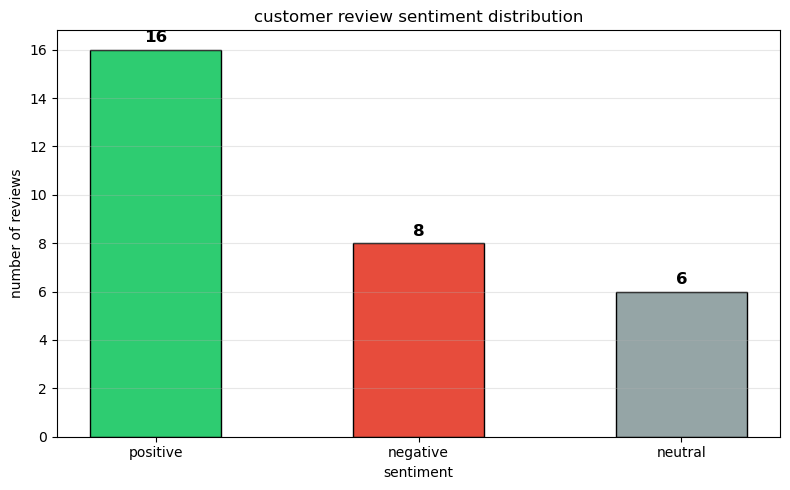

sentiment distribution chart saved!


In [5]:
# bar chart showing how many reviews are
# positive, negative and neutral

colors = {'positive':'#2ECC71', 'negative':'#E74C3C', 'neutral':'#95A5A6'}
sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(sentiment_counts.index,
               sentiment_counts.values,
               color=[colors[s] for s in sentiment_counts.index],
               edgecolor='black',
               width=0.5)

# add numbers on top of each bar
for bar, count in zip(bars, sentiment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             str(count),
             ha='center',
             fontsize=12,
             fontweight='bold')

plt.title('customer review sentiment distribution')
plt.xlabel('sentiment')
plt.ylabel('number of reviews')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('sentiment_distribution.png')
plt.show()
print("sentiment distribution chart saved!")

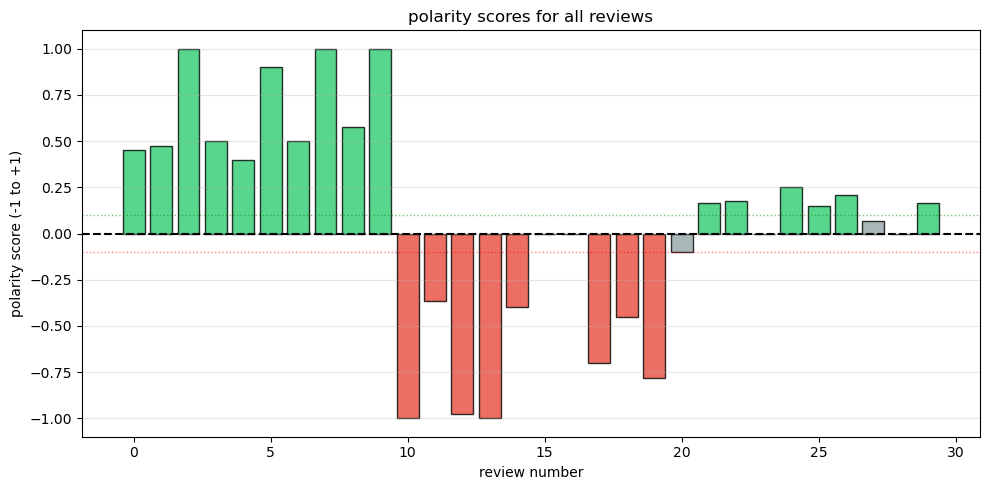

polarity scores chart saved!


In [6]:
# visualize the actual polarity scores for each review
# this shows exactly HOW positive or negative each review is

plt.figure(figsize=(10, 5))

colors_list = [colors[s] for s in df['sentiment']]

plt.bar(range(len(df)),
        df['polarity'],
        color=colors_list,
        edgecolor='black',
        alpha=0.8)

plt.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
plt.axhline(y=0.1, color='green', linewidth=1, linestyle=':', alpha=0.5)
plt.axhline(y=-0.1, color='red', linewidth=1, linestyle=':', alpha=0.5)

plt.title('polarity scores for all reviews')
plt.xlabel('review number')
plt.ylabel('polarity score (-1 to +1)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('polarity_scores.png')
plt.show()
print("polarity scores chart saved!")

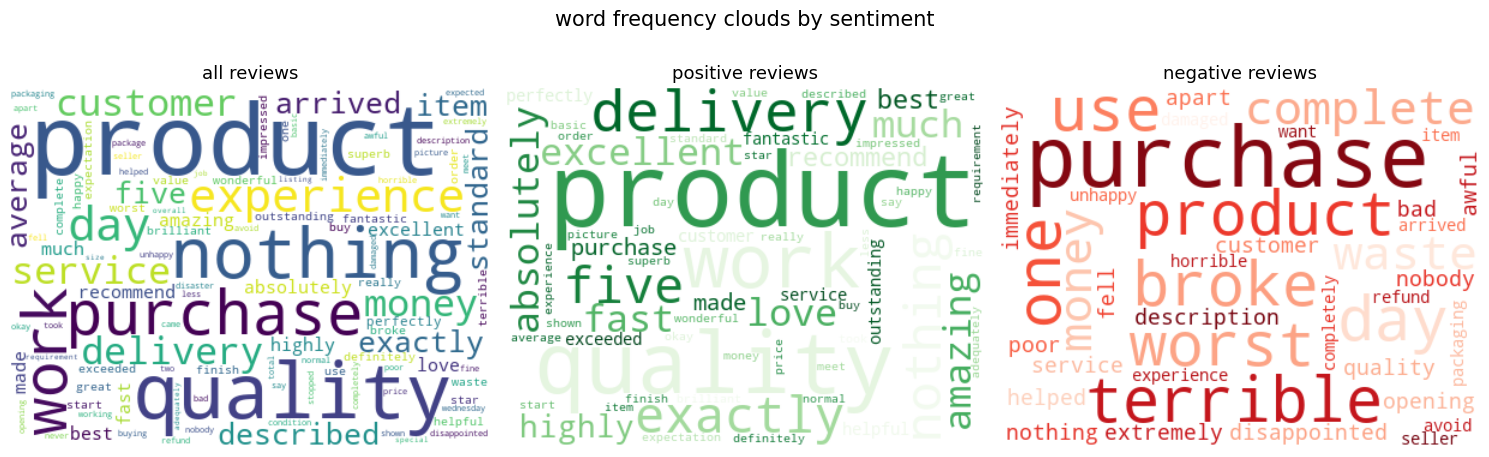

word cloud saved!


In [7]:
# a word cloud shows the most frequently used words
# bigger word = appears more often in the reviews

# separate reviews by sentiment
positive_text = ' '.join(df[df['sentiment']=='positive']['cleaned_review'])
negative_text = ' '.join(df[df['sentiment']=='negative']['cleaned_review'])
all_text      = ' '.join(df['cleaned_review'])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# all reviews word cloud
wc_all = WordCloud(width=400, height=300,
                   background_color='white',
                   colormap='viridis').generate(all_text)
axes[0].imshow(wc_all, interpolation='bilinear')
axes[0].set_title('all reviews', fontsize=13)
axes[0].axis('off')

# positive reviews word cloud
wc_pos = WordCloud(width=400, height=300,
                   background_color='white',
                   colormap='Greens').generate(positive_text)
axes[1].imshow(wc_pos, interpolation='bilinear')
axes[1].set_title('positive reviews', fontsize=13)
axes[1].axis('off')

# negative reviews word cloud
wc_neg = WordCloud(width=400, height=300,
                   background_color='white',
                   colormap='Reds').generate(negative_text)
axes[2].imshow(wc_neg, interpolation='bilinear')
axes[2].set_title('negative reviews', fontsize=13)
axes[2].axis('off')

plt.suptitle('word frequency clouds by sentiment', fontsize=15)
plt.tight_layout()
plt.savefig('wordcloud.png')
plt.show()
print("word cloud saved!")

In [8]:

print("   sentiment analysis complete!          ")


total    = len(df)
positive = len(df[df['sentiment']=='positive'])
negative = len(df[df['sentiment']=='negative'])
neutral  = len(df[df['sentiment']=='neutral'])

print(f"\ntotal reviews analysed : {total}")
print(f"positive reviews       : {positive} ({positive/total*100:.1f}%)")
print(f"negative reviews       : {negative} ({negative/total*100:.1f}%)")
print(f"neutral reviews        : {neutral}  ({neutral/total*100:.1f}%)")
print(f"\naverage polarity score : {df['polarity'].mean():.3f}")
print(f"most positive review   : {df.loc[df['polarity'].idxmax(), 'review']}")
print(f"most negative review   : {df.loc[df['polarity'].idxmin(), 'review']}")
print(f"\nfiles saved:")
print("   - customer_reviews.csv")
print("   - sentiment_distribution.png")
print("   - polarity_scores.png")
print("   - wordcloud.png")

   sentiment analysis complete!          

total reviews analysed : 30
positive reviews       : 16 (53.3%)
negative reviews       : 8 (26.7%)
neutral reviews        : 6  (20.0%)

average polarity score : 0.074
most positive review   : best purchase i have ever made, works perfectly
most negative review   : terrible product, broke after one day of use

files saved:
   - customer_reviews.csv
   - sentiment_distribution.png
   - polarity_scores.png
   - wordcloud.png


In [9]:
import shutil
import os

nltk_path = os.path.expanduser('~/nltk_data')

if os.path.exists(nltk_path):
    shutil.rmtree(nltk_path)
    print("old nltk data deleted!")
else:
    print("no existing nltk data found")

old nltk data deleted!


In [10]:
import nltk

# redownload all required data fresh
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

print("all nltk data downloaded fresh!")

[nltk_data] Downloading package punkt to /home/boss-lady/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /home/boss-
[nltk_data]     lady/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /home/boss-
[nltk_data]     lady/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /home/boss-
[nltk_data]     lady/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/boss-lady/nltk_data...


all nltk data downloaded fresh!


[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
